### Exploration of Receptor Maps

First attempt, mainly following GPT instructions.

I will try to average the maps for:
- GRIN1.pscalar.nii
- GRIN2B.pscalar.nii
- GRIN2D.pscalar.nii
- GRIN3B.pscalar.nii 
- GRIN2A.pscalar.nii
- GRIN2C.pscalar.nii
- GRIN3A.pscalar.nii
- GRINA.pscalar.nii

In [12]:
import nibabel as nib
import numpy as np

data_dir = '/Users/fdjim/Desktop/HBNM/HBNM/data/maps'
# data_dir = '/data/maps'

# Path to your receptor maps
files = [
    f"{data_dir}/GRIN1.pscalar.nii",
    f"{data_dir}/GRIN2A.pscalar.nii", 
    f"{data_dir}/GRIN2B.pscalar.nii",
    f"{data_dir}/GRIN2C.pscalar.nii",
    f"{data_dir}/GRIN2D.pscalar.nii",
    f"{data_dir}/GRIN3A.pscalar.nii",
    f"{data_dir}/GRIN3B.pscalar.nii",
    f"{data_dir}/GRINA.pscalar.nii"
]

# Load and stack maps
receptor_data = []
for f in files:
    img = nib.load(f)
    data = img.get_fdata()  # shape: (num_regions, 1)
    receptor_data.append(data.squeeze())  # convert to 1D

# Shape: (num_maps, num_regions)
receptor_array = np.vstack(receptor_data)


In [14]:
# Inspect value ranges and means for each receptor map
for fname, vec in zip(files, receptor_data):
    print(f"{fname.split('/')[-1]}:")
    print(f"  Mean:  {np.mean(vec):.4f}")
    print(f"  Min:   {np.min(vec):.4f}")
    print(f"  Max:   {np.max(vec):.4f}")
    print(f"  Std:   {np.std(vec):.4f}")
    print()

GRIN1.pscalar.nii:
  Mean:  0.0000
  Min:   -2.5934
  Max:   3.1299
  Std:   0.9972

GRIN2A.pscalar.nii:
  Mean:  0.0000
  Min:   -3.3803
  Max:   2.9094
  Std:   0.9972

GRIN2B.pscalar.nii:
  Mean:  0.0000
  Min:   -2.5840
  Max:   2.4341
  Std:   0.9972

GRIN2C.pscalar.nii:
  Mean:  0.0000
  Min:   -2.9241
  Max:   2.3887
  Std:   0.9972

GRIN2D.pscalar.nii:
  Mean:  -0.0000
  Min:   -3.6450
  Max:   2.7186
  Std:   0.9972

GRIN3A.pscalar.nii:
  Mean:  -0.0000
  Min:   -2.6998
  Max:   2.4142
  Std:   0.9972

GRIN3B.pscalar.nii:
  Mean:  -0.0000
  Min:   -1.9115
  Max:   2.5937
  Std:   0.9972

GRINA.pscalar.nii:
  Mean:  0.0000
  Min:   -3.0294
  Max:   2.1897
  Std:   0.9972



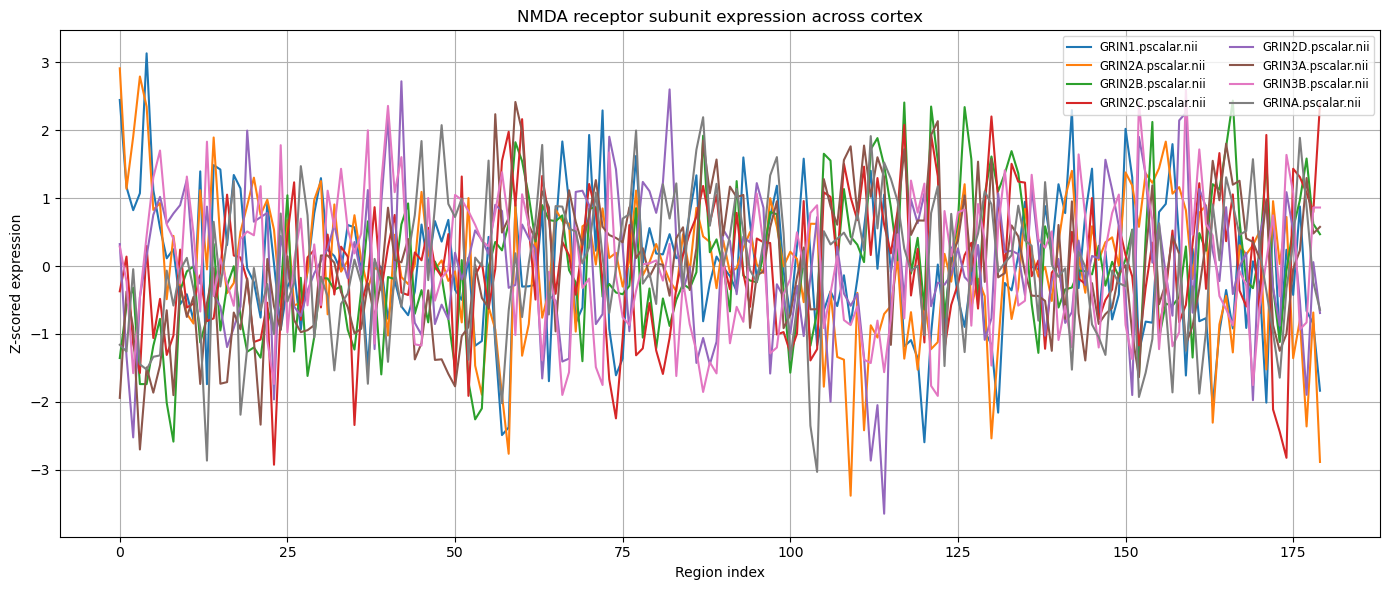

In [22]:
# Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
for i, (fname, vec) in enumerate(zip(files, receptor_data)):
    plt.plot(vec, label=fname.split('/')[-1])

plt.xlabel("Region index")
plt.ylabel("Z-scored expression")
plt.title("NMDA receptor subunit expression across cortex")
plt.legend(loc='upper right', fontsize='small', ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()

In [21]:
img = nib.load("data/maps/NMDA_avg.pscalar.nii")
data = img.get_fdata()  # shape: (num_regions, 1)
avg_map = data.squeeze()  # convert to 1D
avg_map

print("NMDA_avg.pscalar.nii:")
print(f"  Mean:  {np.mean(avg_map):.4f}")
print(f"  Min:   {np.min(avg_map):.4f}")
print(f"  Max:   {np.max(avg_map):.4f}")
print(f"  Std:   {np.std(avg_map):.4f}")


NMDA_avg.pscalar.nii:
  Mean:  0.0000
  Min:   -1.1051
  Max:   0.7934
  Std:   0.3002


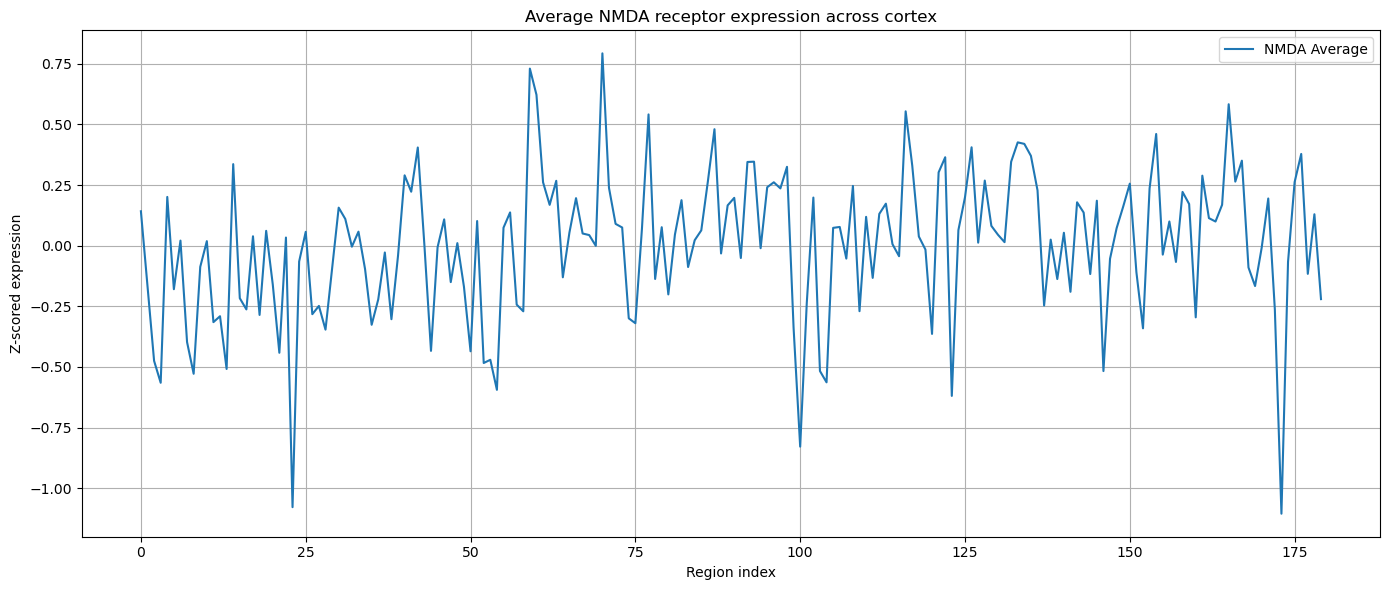

In [23]:
plt.figure(figsize=(14, 6))
plt.plot(avg_map, label='NMDA Average')
plt.xlabel("Region index")
plt.ylabel("Z-scored expression") 
plt.title("Average NMDA receptor expression across cortex")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Add the NMDA Map to the data object

In [3]:
import h5py
from hbnm.io import Data
 
# Load the data
data_handler = Data("/Users/fdjim/Desktop/HBNM/HBNM/data/", "/Users/fdjim/Desktop/HBNM/HBNM/outputs/")
hdf5_file = data_handler.load('demirtas_neuron_2019.hdf5')

In [4]:
print("Root keys:", list(hdf5_file.keys()))

Root keys: ['alphabeta_removed_meg_pc1', 'apprx_posterior_heterogeneous', 'apprx_posterior_homogeneous', 'fc', 'fc_heterogeneous', 'fc_homogeneous', 'heterogeneity_maps', 'raw_meg_pc1', 'sc', 't1wt2w']


In [8]:
h_maps = hdf5_file['heterogeneity_maps'][:]

In [9]:
h_maps

array([[ 2.15261310e-02,  4.47963958e-01,  6.58573866e-01, ...,
         4.13393964e-01,  6.08568368e-01,  8.20777366e-01],
       [ 4.81634385e-02,  2.66269905e-04,  2.46706746e-01, ...,
         7.18845589e-01, -0.00000000e+00,  9.54531788e-01],
       [ 5.55657315e-02,  4.48570279e-01,  5.49017356e-01, ...,
         1.61252806e-01,  8.14872505e-01,  4.85586770e-01],
       ...,
       [ 9.57053511e-01,  4.13165548e-01,  4.16947104e-01, ...,
         7.00331690e-01,  2.51624129e-01,  2.54080593e-01],
       [ 8.85195986e-01,  9.57053511e-01,  9.26837385e-01, ...,
         9.21152316e-01,  9.67382761e-01,  6.49116799e-01],
       [ 9.77245716e-01,  9.49915083e-01,  8.64327456e-01, ...,
         9.57053511e-01,  9.26837385e-01,  6.75916942e-01]],
      shape=(360, 10))